# Preprocessing pipeline

Runs the full pipeline on a BCI2000 recording:
1. Load with `load_bci2k`
2. Bandpass filter [1–55 Hz], 4th-order Butterworth
3. Re-reference to average
4. ICA (extended Infomax, 24 components)
5. ICLabel classification
6. Plot first 2 components with ICLabel annotations

In [7]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from eeg.io import load_bci2k
from eeg.inspect import print_summary
from eeg.preprocessing import bandpass_filter, rereference_average, run_ica, label_components
from eeg.viz import plot_ica_components, plot_stim_channel, plot_channels, plot_channels_psd

DATA_FILE = PROJECT_ROOT / "data/eeg/raw/MET000bGridFixedS001R02.dat"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load

In [2]:
raw = load_bci2k(DATA_FILE)
print_summary(raw)

Creating RawArray with float64 data, n_channels=1, n_times=209984
    Range : 0 ... 209983 =      0.000 ...   410.123 secs
Ready.
EEG channels (32): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4']
All channels (33): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4', 'STI 014']
Sampling rate: 512.0 Hz
Duration: 410.12 s
Montage: <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 32 channels>
Stimulus channel: STI 014 (from DigitalInput1)
Finding events on: STI 014
104 events found on stim channel STI 014
Event IDs: [1]
DigitalInput1 rising edges: 104
Events (find_events): 104
Event counts: {1: 104}


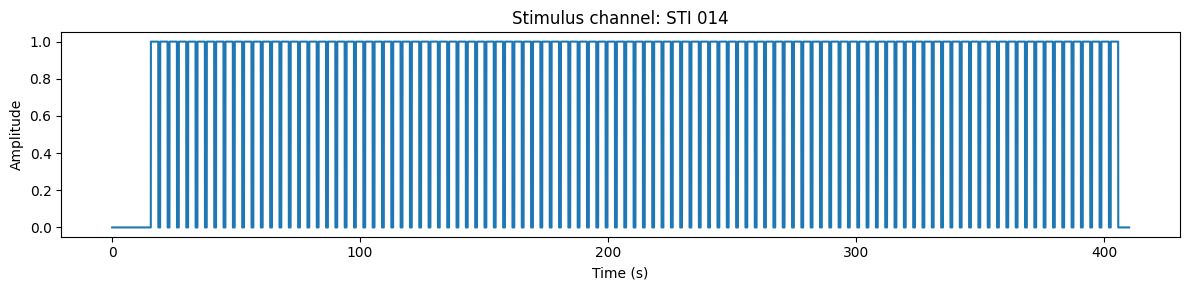

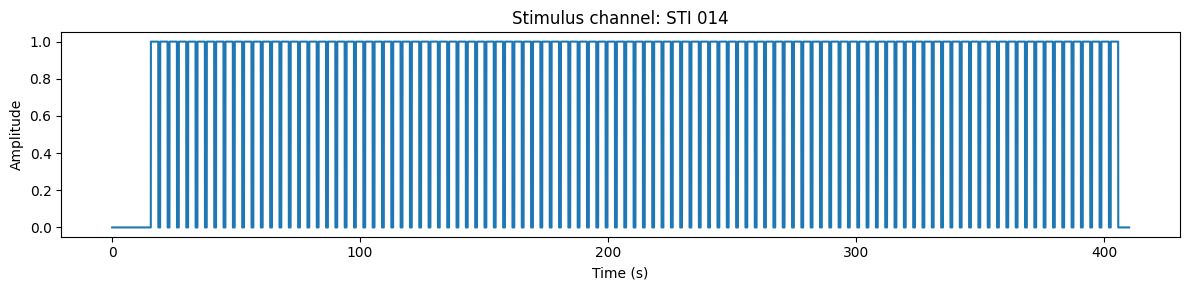

In [3]:
plot_stim_channel(raw, 600)

## 2. Bandpass filter

In [4]:
L_FREQ = 1.0
H_FREQ = 55.0
FILTER_ORDER = 4

bandpass_filter(raw, l_freq=L_FREQ, h_freq=H_FREQ, order=FILTER_ORDER)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 55 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 55.00 Hz: -6.02, -6.02 dB


<RawBCI2k | MET000bGridFixedS001R02.dat, 33 x 209984 (410.1 s), ~52.9 MiB, data loaded>

## 3. Re-reference to average

In [5]:
rereference_average(raw)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBCI2k | MET000bGridFixedS001R02.dat, 33 x 209984 (410.1 s), ~52.9 MiB, data loaded>

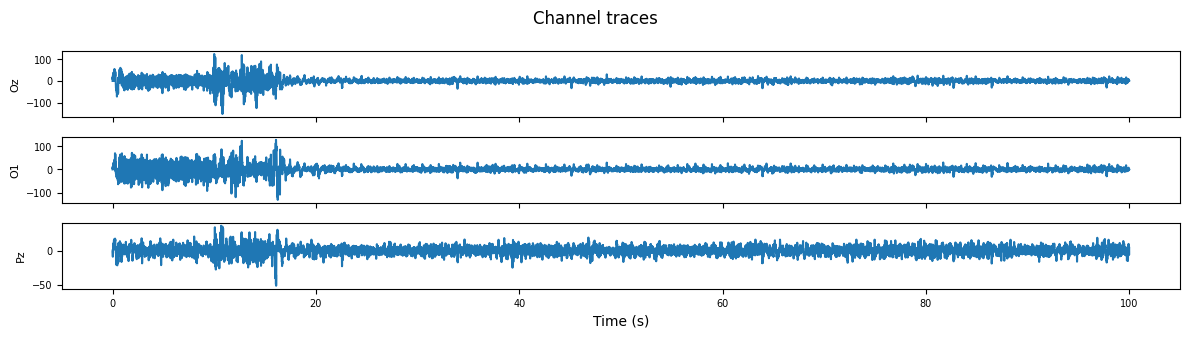

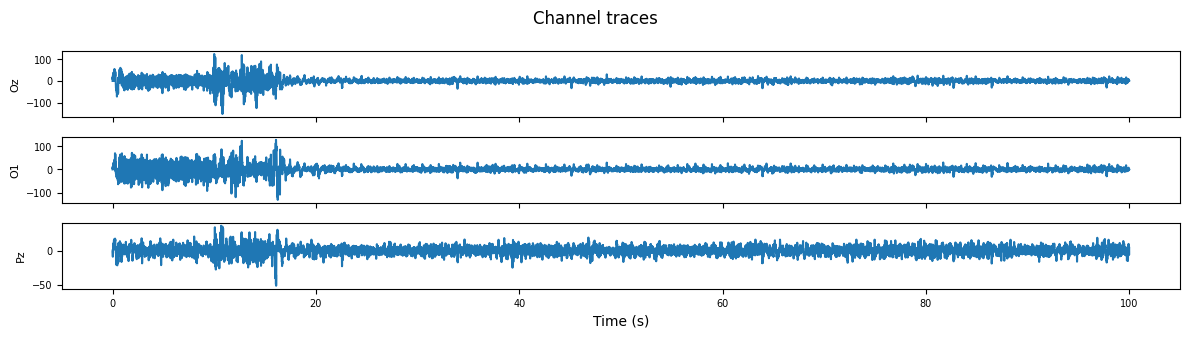

In [6]:
CHANNELS = ["Oz", "O1", "Pz"]  # change to any channel names
DURATION = 100.0  # seconds to show

plot_channels(raw, CHANNELS, duration=DURATION)

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


/home/zevaz/projects/dataAnalysisCursor/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


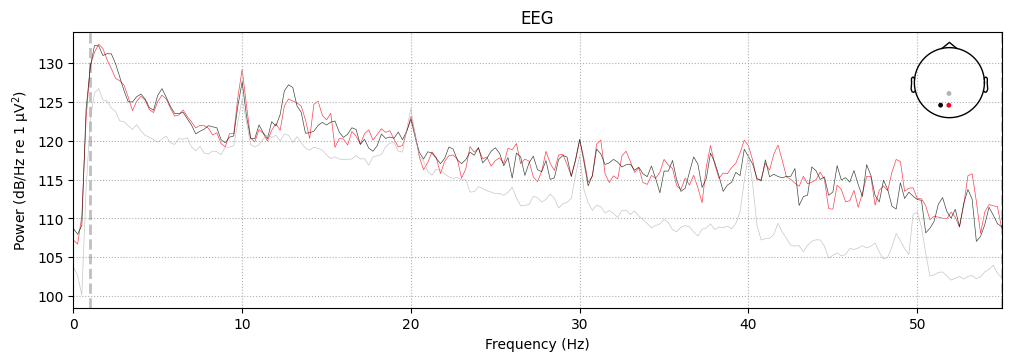

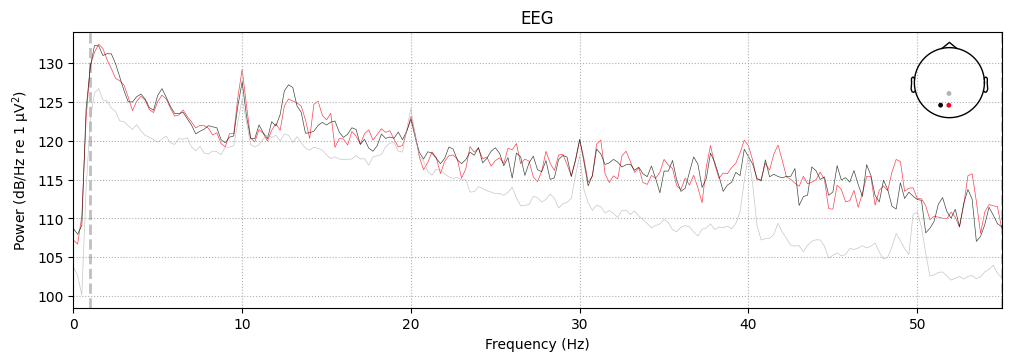

In [8]:
FMAX = 55.0  # Hz

plot_channels_psd(raw, CHANNELS, fmax=FMAX)

## 4. ICA

Takes ~60–90 seconds.

In [10]:
N_COMPONENTS = 24

ica = run_ica(raw, n_components=N_COMPONENTS)
print(ica)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 24 components
Computing Extended Infomax ICA
Fitting ICA took 40.7s.
<ICA | raw data decomposition, method: infomax (fit in 173 iterations on 209984 samples), 24 ICA components (32 PCA components available), channel types: eeg, no sources marked for exclusion>


## 5. ICLabel

In [11]:
labels = label_components(raw, ica)

for i, (label, proba) in enumerate(zip(labels["labels"], labels["y_pred_proba"])):
    print(f"IC {i:02d}: {label} ({proba.max():.0%})")

/home/zevaz/projects/dataAnalysisCursor/src/eeg/preprocessing.py:52: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  return mne_icalabel.label_components(raw, ica, method="iclabel")


IC 00: other (86%)
IC 01: eye blink (96%)
IC 02: brain (100%)
IC 03: brain (91%)
IC 04: brain (100%)
IC 05: brain (97%)
IC 06: brain (100%)
IC 07: muscle artifact (52%)
IC 08: brain (93%)
IC 09: eye blink (85%)
IC 10: brain (97%)
IC 11: brain (57%)
IC 12: brain (86%)
IC 13: brain (100%)
IC 14: other (44%)
IC 15: other (38%)
IC 16: other (48%)
IC 17: brain (100%)
IC 18: other (56%)
IC 19: other (70%)
IC 20: other (60%)
IC 21: brain (60%)
IC 22: other (50%)
IC 23: brain (96%)


## 6. Plot first 2 components

Change `COMPONENT_INDICES` to inspect different components.

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_15008/271178456.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


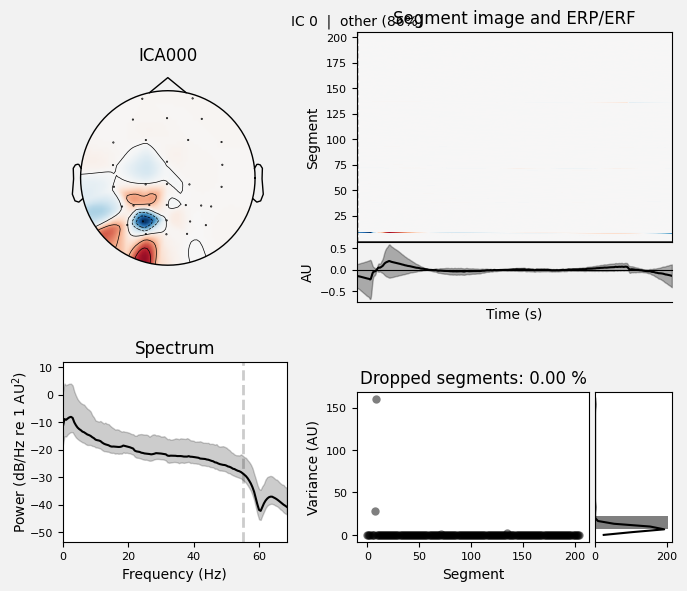

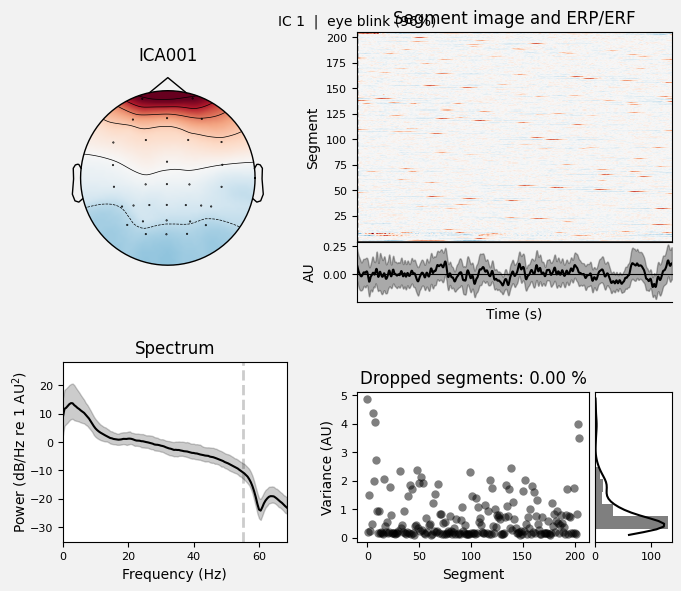

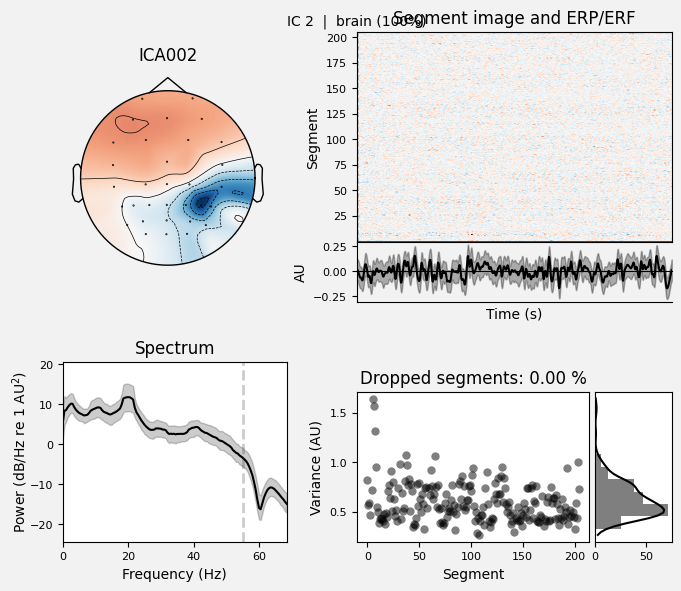

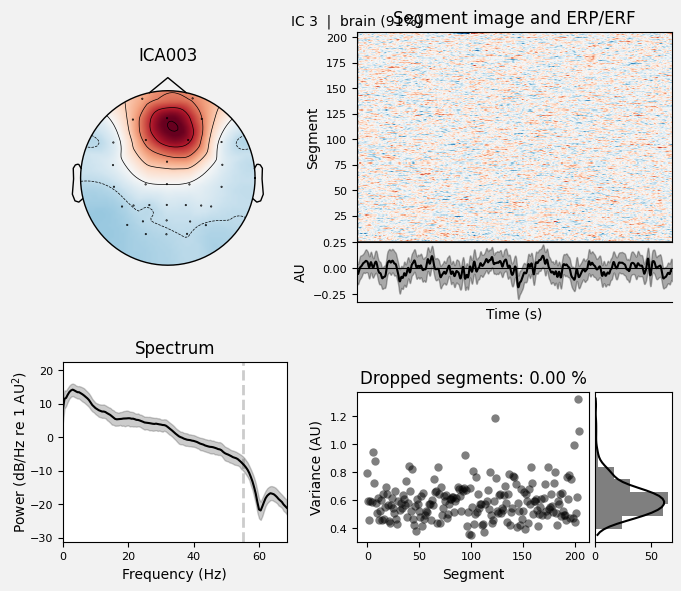

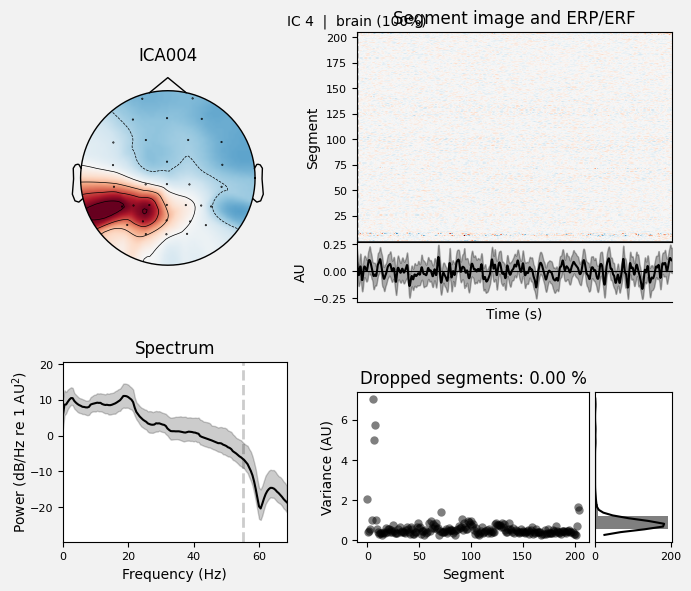

In [12]:
COMPONENT_INDICES = [0, 1, 2, 3, 4]

figs = plot_ica_components(raw, ica, COMPONENT_INDICES, labels=labels)
for fig in figs:
    fig.show()